In [282]:
import pandas as pd


train = pd.read_csv(r"RandomForest\RFR\FoodDemand_Forecasting\train.csv")
test = pd.read_csv(r"RandomForest\RFR\FoodDemand_Forecasting\test.csv")
sample_submission = pd.read_csv(r"RandomForest\RFR\FoodDemand_Forecasting\sample_submission.csv")
center_info = pd.read_csv(r"RandomForest\RFR\FoodDemand_Forecasting\fulfilment_center_info.csv")
meal_info = pd.read_csv(r"RandomForest\RFR\FoodDemand_Forecasting\meal_info.csv")

In [283]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 31.3 MB


In [284]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32573 entries, 0 to 32572
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     32573 non-null  int64  
 1   week                   32573 non-null  int64  
 2   center_id              32573 non-null  int64  
 3   meal_id                32573 non-null  int64  
 4   checkout_price         32573 non-null  float64
 5   base_price             32573 non-null  float64
 6   emailer_for_promotion  32573 non-null  int64  
 7   homepage_featured      32573 non-null  int64  
dtypes: float64(2), int64(6)
memory usage: 2.0 MB


In [285]:
center_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   center_id    77 non-null     int64  
 1   city_code    77 non-null     int64  
 2   region_code  77 non-null     int64  
 3   center_type  77 non-null     object 
 4   op_area      77 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 3.1+ KB


In [286]:
meal_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   meal_id   51 non-null     int64 
 1   category  51 non-null     object
 2   cuisine   51 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.3+ KB


In [287]:
sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32573 entries, 0 to 32572
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          32573 non-null  int64
 1   num_orders  32573 non-null  int64
dtypes: int64(2)
memory usage: 509.1 KB


In [288]:
sample_submission.head()

,id,num_orders
0,1028232,0
1,1127204,0
2,1212707,0
3,1082698,0
4,1400926,0


"train" and "test" contains all id.
"test" doesn't contain the target column (num_orders).
"meal info" will be merged with both the dataset on the basis of 'meal_id'.
"center_info" will be merged with both the dataset on the basis of 'center_id'.

In [289]:
train_full = (train.merge(meal_info, on = "meal_id", how = "left")).merge(center_info, on = "center_id", how = "left")

train_full.head(10)

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.0
5,1270037,1,55,1248,251.23,252.23,0,0,28,Beverages,Indian,647,56,TYPE_C,2.0
6,1191377,1,55,1778,183.36,184.36,0,0,190,Beverages,Italian,647,56,TYPE_C,2.0
7,1499955,1,55,1062,182.36,183.36,0,0,391,Beverages,Italian,647,56,TYPE_C,2.0
8,1025244,1,55,2707,193.06,192.06,0,0,472,Beverages,Italian,647,56,TYPE_C,2.0
9,1054194,1,55,1207,325.92,384.18,0,1,676,Beverages,Continental,647,56,TYPE_C,2.0


In [290]:
test_full = (test.merge(meal_info, on = "meal_id", how = "left")).merge(center_info, on = "center_id", how = "left")

test_full.head()
test_full.drop(columns = ["id"], inplace = True)

test_full.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 32573 entries, 0 to 32572
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   week                   32573 non-null  int64  
 1   center_id              32573 non-null  int64  
 2   meal_id                32573 non-null  int64  
 3   checkout_price         32573 non-null  float64
 4   base_price             32573 non-null  float64
 5   emailer_for_promotion  32573 non-null  int64  
 6   homepage_featured      32573 non-null  int64  
 7   category               32573 non-null  object 
 8   cuisine                32573 non-null  object 
 9   city_code              32573 non-null  int64  
 10  region_code            32573 non-null  int64  
 11  center_type            32573 non-null  object 
 12  op_area                32573 non-null  float64
dtypes: float64(3), int64(7), object(3)
memory usage: 3.5+ MB


In [291]:
train_full.isna().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64

In [292]:
train_full.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64

**id**: Unique identifier for each row (each center–meal–week combination)

**week**: Week number in the timeline (1, 2, 3, …). Used to capture time trends and seasonality.  

**meal_id**: ID of the specific meal (e.g., a particular dish on the menu). Used to join with meal_info.csv and to model meal-specific demand patterns.  

**category**: Type of meal, like beverages, snacks, soup, etc.  

**cuisine**: Cuisine type, such as Indian, Italian, etc.  

**checkout_price**: Final price the customer pays after discounts, taxes, and delivery charges.  

**base_price**: Original menu price before discounts and promotions.  

**emailer_for_promotion**: 1 if the meal was promoted via email that week, 0 if not.  

**homepage_featured**: 1 if the meal was featured on the website homepage, 0 if not.  

**center_id**: ID of the fulfilment center (like a warehouse or kitchen) that prepares and delivers the meal; used to join with fulfilment_center_info.csv.  

**city_code**: Encoded identifier for the city where this center operates.  

**region_code**: Encoded identifier for the broader region of that city.  

**center_type**: Category of center size/capacity, typically something like Type A, B, C.  

**op_area**: Operational area of the center, usually the service area size in square kilometers.  

**num_orders**: Number of orders received for that center–meal–week combination.

In [293]:
train_full.dtypes

id                         int64
week                       int64
center_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                 int64
category                  object
cuisine                   object
city_code                  int64
region_code                int64
center_type               object
op_area                  float64
dtype: object

In [294]:
train_full.drop(columns  = 'id', inplace = True)

The deep analysis

In [295]:
train_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 456548 entries, 0 to 456547
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   week                   456548 non-null  int64  
 1   center_id              456548 non-null  int64  
 2   meal_id                456548 non-null  int64  
 3   checkout_price         456548 non-null  float64
 4   base_price             456548 non-null  float64
 5   emailer_for_promotion  456548 non-null  int64  
 6   homepage_featured      456548 non-null  int64  
 7   num_orders             456548 non-null  int64  
 8   category               456548 non-null  object 
 9   cuisine                456548 non-null  object 
 10  city_code              456548 non-null  int64  
 11  region_code            456548 non-null  int64  
 12  center_type            456548 non-null  object 
 13  op_area                456548 non-null  float64
dtypes: float64(3), int64(8), object(3)
m

In [296]:
train_full.isna().sum()

week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64

In [297]:
train_full.isnull().sum()

week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64

In [298]:
import matplotlib.pyplot as plt

In [299]:
target = ["num_orders"]

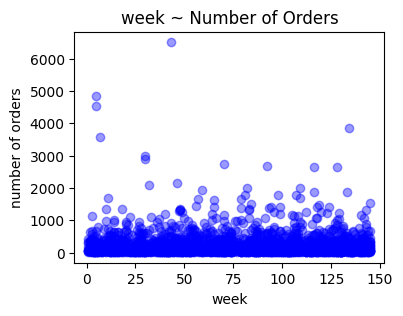

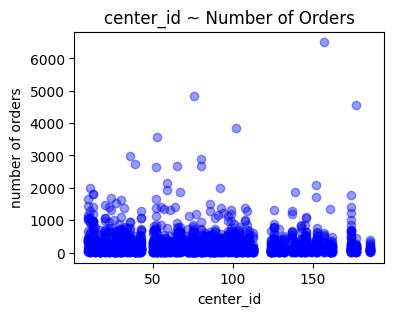

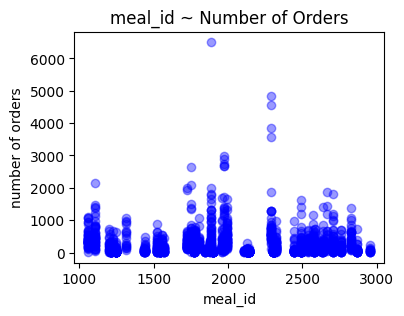

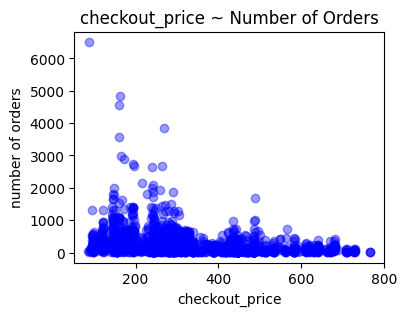

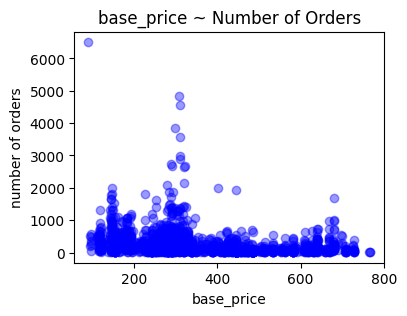

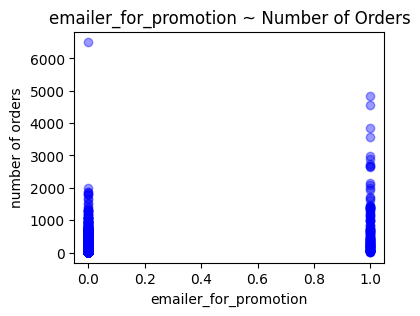

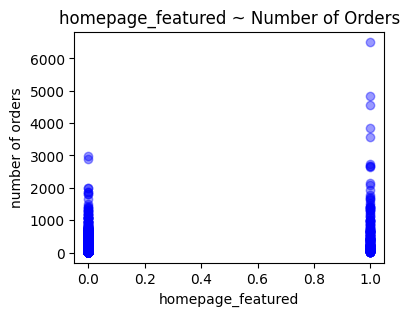

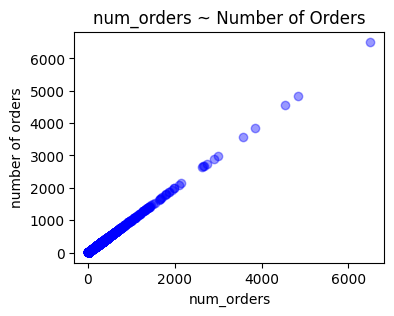

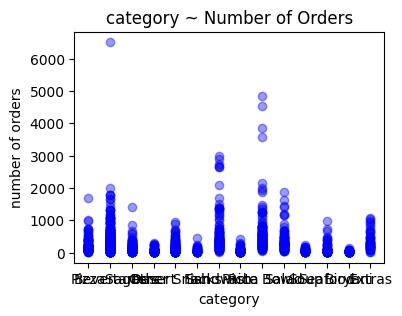

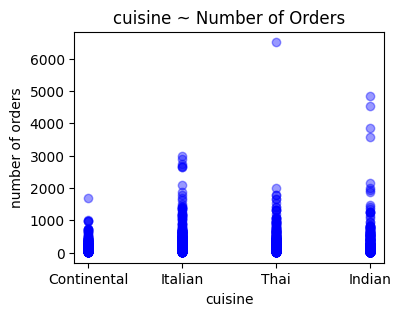

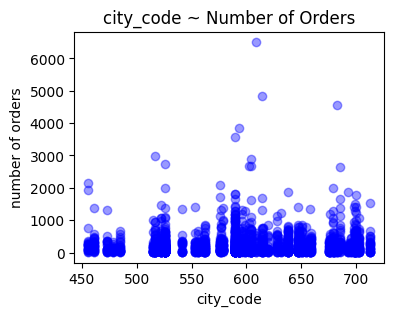

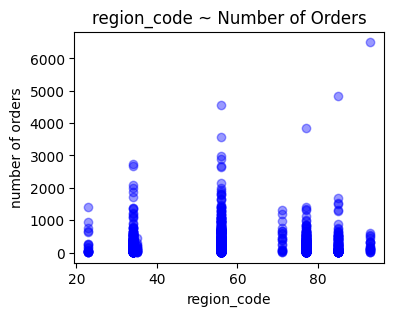

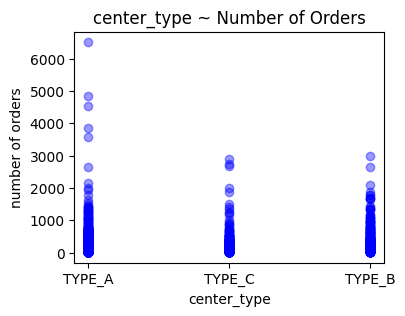

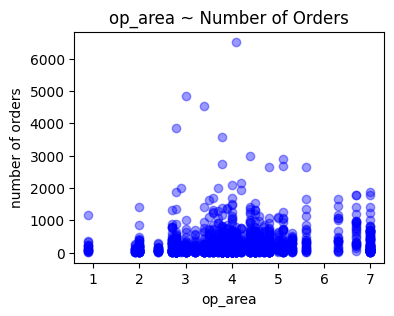

In [300]:

for col in train_full.columns:
    if col == target:
        continue
    plt.figure(figsize = (4,3))
    sample = train_full.sample(2000, random_state = 42) #SINCE THERE ARE 456548 rows we need to create a sample with 2k rows only for less complex graph
    plt.scatter(sample[col], sample["num_orders"], color = 'blue', alpha = 0.4)
    plt.xlabel(col)
    plt.ylabel(f"number of orders")
    plt.title(f"{col} ~ Number of Orders")
    plt.tight_layout
    plt.show()

In [301]:
train_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 456548 entries, 0 to 456547
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   week                   456548 non-null  int64  
 1   center_id              456548 non-null  int64  
 2   meal_id                456548 non-null  int64  
 3   checkout_price         456548 non-null  float64
 4   base_price             456548 non-null  float64
 5   emailer_for_promotion  456548 non-null  int64  
 6   homepage_featured      456548 non-null  int64  
 7   num_orders             456548 non-null  int64  
 8   category               456548 non-null  object 
 9   cuisine                456548 non-null  object 
 10  city_code              456548 non-null  int64  
 11  region_code            456548 non-null  int64  
 12  center_type            456548 non-null  object 
 13  op_area                456548 non-null  float64
dtypes: float64(3), int64(8), object(3)
m

In [302]:
test_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32573 entries, 0 to 32572
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   week                   32573 non-null  int64  
 1   center_id              32573 non-null  int64  
 2   meal_id                32573 non-null  int64  
 3   checkout_price         32573 non-null  float64
 4   base_price             32573 non-null  float64
 5   emailer_for_promotion  32573 non-null  int64  
 6   homepage_featured      32573 non-null  int64  
 7   category               32573 non-null  object 
 8   cuisine                32573 non-null  object 
 9   city_code              32573 non-null  int64  
 10  region_code            32573 non-null  int64  
 11  center_type            32573 non-null  object 
 12  op_area                32573 non-null  float64
dtypes: float64(3), int64(7), object(3)
memory usage: 3.5+ MB


In [303]:
obj_col = ["category", "cuisine", "center_type"]
num_col = ["checkout_price", "base_price", "op_area"]
encode_col = ["center_id", "meal_id"]
no_change = ["week", "emailer_for_promotion", "homepage_featured", "city_code", "region_code"]
target = ["num_orders"]

In [304]:
train_full.head()

,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0
2,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0
3,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.0
4,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.0


In [305]:
from sklearn.preprocessing import LabelEncoder

to_encode = encode_col + obj_col

encoder = {}

for col in to_encode:
    le = LabelEncoder()
    train_full[col] = le.fit_transform(train_full[col])
    test_full[col] = le.transform(test_full[col])
    encoder[col] = le

In [306]:
train_full.head()

,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1,23,22,136.83,152.29,0,0,177,0,3,647,56,2,2.0
1,1,23,26,136.83,135.83,0,0,270,0,3,647,56,2,2.0
2,1,23,38,134.86,135.86,0,0,189,0,3,647,56,2,2.0
3,1,23,29,339.50,437.53,0,0,54,0,1,647,56,2,2.0
4,1,23,42,243.50,242.50,0,0,40,0,1,647,56,2,2.0


In [307]:
encoder

{'center_id': LabelEncoder(),
 'meal_id': LabelEncoder(),
 'category': LabelEncoder(),
 'cuisine': LabelEncoder(),
 'center_type': LabelEncoder()}

obj_col = ["category", "cuisine", "center_type"]

num_col = ["checkout_price", "base_price", "op_area"]

encode_col = ["center_id", "meal_id"]

no_change = ["week", "emailer_for_promotion", "homepage_featured", "city_code", "region_code"]

target = ["num_orders"]

#### outlier detection and resolution

In [308]:
import seaborn as sns

for category, cuisine and center_type (no outliers so far)

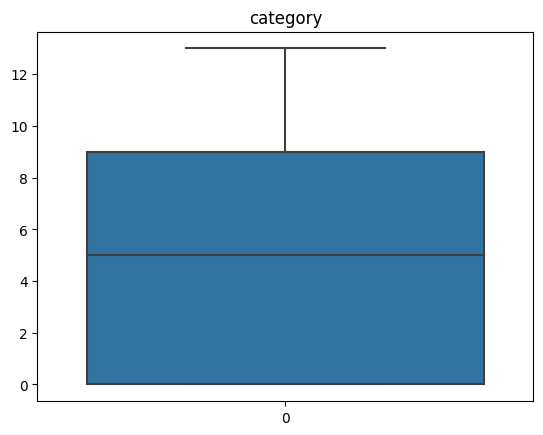

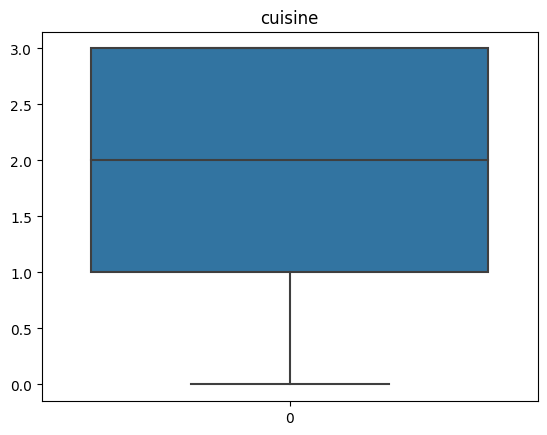

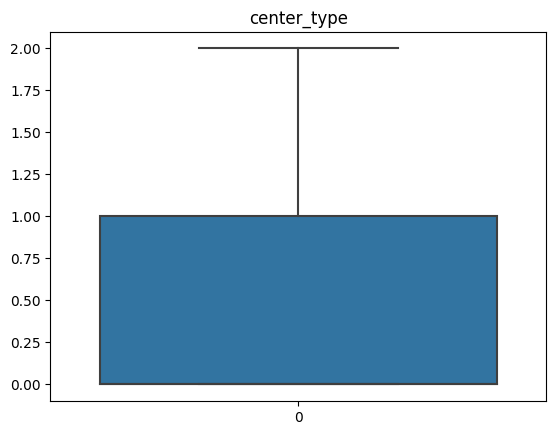

In [309]:
for col in obj_col:
    sns.boxplot(train_full[col])
    plt.title(col)
    plt.show()


for "checkout_price", "base_price", "op_area"

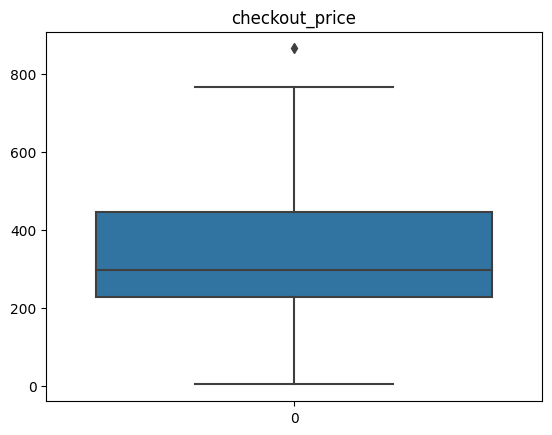

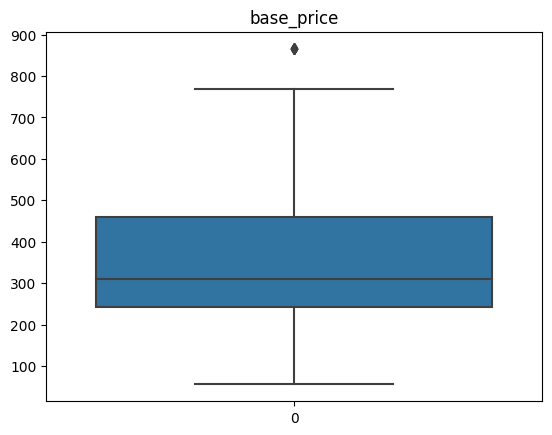

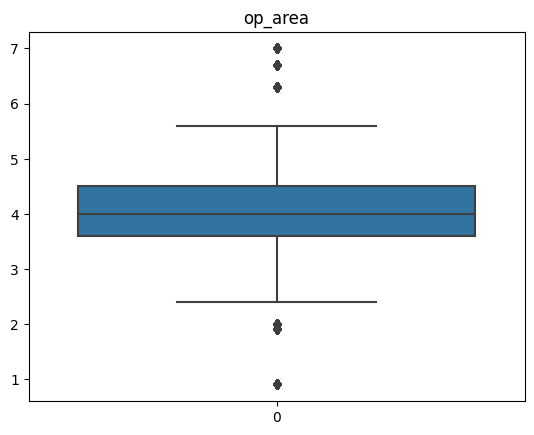

In [310]:
for col in num_col:
    sns.boxplot(train_full[col])
    plt.title(col)
    plt.show()

creating pipeline

In [311]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators = 300, max_depth = None, min_samples_split = 2, n_jobs = -1, random_state = 42)

all_features = num_col + obj_col + encode_col + no_change

preprocess = ColumnTransformer(transformers = [('no_change', 'passthrough', all_features)], remainder = "drop")

model = Pipeline(steps = [('pre', preprocess), ('rfr', rfr)])

In [312]:
train_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 456548 entries, 0 to 456547
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   week                   456548 non-null  int64  
 1   center_id              456548 non-null  int64  
 2   meal_id                456548 non-null  int64  
 3   checkout_price         456548 non-null  float64
 4   base_price             456548 non-null  float64
 5   emailer_for_promotion  456548 non-null  int64  
 6   homepage_featured      456548 non-null  int64  
 7   num_orders             456548 non-null  int64  
 8   category               456548 non-null  int32  
 9   cuisine                456548 non-null  int32  
 10  city_code              456548 non-null  int64  
 11  region_code            456548 non-null  int64  
 12  center_type            456548 non-null  int32  
 13  op_area                456548 non-null  float64
dtypes: float64(3), int32(3), int64(8)
me

In [313]:
num_col + obj_col + encode_col + no_change

['checkout_price',
 'base_price',
 'op_area',
 'category',
 'cuisine',
 'center_type',
 'center_id',
 'meal_id',
 'week',
 'emailer_for_promotion',
 'homepage_featured',
 'city_code',
 'region_code']

In [314]:
from sklearn.model_selection import train_test_split

X = train_full.drop(columns = target)
y = train_full[target]

[X_train, X_test, y_train, y_test] = train_test_split(X,y, test_size = 0.2, random_state = 42)

print(X_train.shape)
print(y_train.shape)


(365238, 13)
(365238, 1)


In [315]:
X_train.head()

,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,category,cuisine,city_code,region_code,center_type,op_area
343260,111,28,7,138.74,154.26,0,0,0,1,553,77,0,4.4
145850,50,56,16,261.93,309.43,0,1,10,2,599,56,0,3.6
54151,19,15,36,447.23,446.23,0,0,2,1,526,34,2,3.8
231471,77,41,11,244.50,291.03,0,1,5,3,659,77,0,5.3
445928,142,26,37,194.00,194.00,0,0,12,3,456,56,0,4.2


In [316]:
y_train.head()

,num_orders
343260,14
145850,501
54151,13
231471,257
445928,134


In [317]:
model.fit(X_train, y_train)

c:\users\lenovo\.pyenv\pyenv-win\versions\3.7.4\lib\site-packages\sklearn\pipeline.py:394: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('no_change', 'passthrough',
                                                  ['checkout_price',
                                                   'base_price', 'op_area',
                                                   'category', 'cuisine',
                                                   'center_type', 'center_id',
                                                   'meal_id', 'week',
                                                   'emailer_for_promotion',
                                                   'homepage_featured',
                                                   'city_code',
                                                   'region_code'])])),
                ('rfr',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [318]:
y_pred_train = model.predict(X_test)

In [319]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_train)
mse = mean_squared_error(y_test, y_pred_train)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_train)

print(f"Mean absolute error : {mae}\nMean squared error : {mse}\nRoot MSE : {rmse}\nr2 score : {r2}")

Mean absolute error : 67.71581743511116
Mean squared error : 20376.771476764017
Root MSE : 142.74722931379094
r2 score : 0.8664111480654936


In [320]:
y_pred_original = model.predict(test_full)

In [321]:
sample_submission["num_orders"] = y_pred_original
sample_submission.head()

,id,num_orders
0,1028232,104.943333
1,1127204,90.793333
2,1212707,133.593333
3,1082698,70.810000
4,1400926,52.816667


In [322]:
sample_submission.to_csv("my_submission.csv", index = False)